# Proyecto Integrador — Machine Learning  
## Módulo: Machine Learning | Soy Henry

**Estudiante:** Vanina Cavallin  
**Proyecto:** Predicción de Churn de Clientes  
**Empresa ficticia:** FinanceGuard  
**Avance:** Nº 3 — Integración y Cierre  

**Fecha:** 09/02/2026  

---

# Consigna:
### **Objetivo:** descubrir segmentos con comportamientos diferenciados y analizar su relación con la tasa de **churn** (`Exited`).

### **Detalles del avance:**
## 1. Clustering básico para segmentación:
### K-Means clustering:
- Conceptos fundamentales: centroides, iteraciones
- Selección del número de clusters K:
        - Método del codo (Elbow method).
        - Coeficiente de silueta (Silhouette score).
- Implementación paso a paso.
- Interpretación de centroides.
- Visualización de clusters en 2D.
### DBSCAN (Density-Based clustering):
- Conceptos: core points, border points, noise.
- Parámetros básicos: eps (epsilon) y min_samples.
- Ventajas: detecta outliers, no requiere definir K.
- Comparación con K-means.

## 2. Reducción de dimensionalidad:
### PCA (Principal Component Analysis):
- Conceptos básicos: componentes principales.
- Varianza explicada por cada componente.
- Selección del número de componentes.
- Visualización de datos en 2D y 3D.
- Interpretación de los componentes principales.
### t-SNE básico:
- Visualización no lineal de datos.
- Parámetro perplexity (concepto básico).
- Diferencias con PCA.
- Limitaciones y cuidados en interpretación.

## 3. 	Aplicación al problema de churn:
### Segmentación de clientes:
- Aplicar K-means al dataset de clientes
- Identificar 3-5 segmentos principales
- Analizar características de cada segmento
- Tasa de churn por segmento identificado
### Perfiles de clientes por cluster:
- Características demográficas y comportamiento por cluster
- Crear features derivadas del clustering

**Entregar el notebook 3_AprendizajeNoSupervisado.ipynb donde se implementen técnicas de clustering (K-Means y DBSCAN) para segmentar la base de clientes, y se apliquen reducción de dimensionalidad (PCA y t-SNE) para visualizar patrones en los datos.** 

---

## 1) Setup y carga del dataset

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

---

## 2) Carga del dataset

In [3]:
# Cargar dataset
path = "Churn_Modelling.csv"
df = pd.read_csv(path)

print("Shape:", df.shape)
display(df.head())

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---

## 3) Separación del target y selección de variables para clustering

**Objetivo:**  
- Preparar el conjunto de variables para clustering, separando el target únicamente para análisis posterior.

**Qué hace este bloque:**  
- Paso 1: Define la variable objetivo `Exited`.  
- Paso 2: Elimina columnas identificadoras que no aportan valor al clustering.  
- Paso 3: Separa features (`X_raw`) y target (`y`).  
- Paso 4: Identifica columnas numéricas y categóricas.

**Inputs:**  
- `df`: dataset original.

**Outputs:**  
- `X_raw`: variables explicativas sin target ni identificadores.  
- `y`: variable objetivo (solo para análisis posterior).  
- `num_cols`, `cat_cols`: listas de columnas.

**Notas / Buenas prácticas:**  
- El target **no debe usarse para entrenar clustering** (evita leakage conceptual).  
- Los identificadores pueden inducir clusters artificiales.

In [4]:
# Separar target (para análisis posterior, NO para clustering)
target_col = "Exited"

# Columnas a descartar (identificadores / texto)
drop_cols = ["RowNumber", "CustomerId", "Surname"]

X_raw = df.drop(columns=drop_cols + [target_col])
y = df[target_col].copy()

cat_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_raw.columns if c not in cat_cols]

print("Num cols:", num_cols)
print("Cat cols:", cat_cols)

Num cols: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Cat cols: ['Geography', 'Gender']


---

## 4) Preprocesamiento: One-Hot Encoding y escalado

**Objetivo:**  
- Transformar las variables para que sean compatibles con algoritmos basados en distancia.

**Qué hace este bloque:**  
- Paso 1: Aplica `StandardScaler` a variables numéricas.  
- Paso 2: Aplica `OneHotEncoder` a variables categóricas.  
- Paso 3: Construye una matriz final transformada (`X`).  
- Paso 4: Recupera nombres de features para interpretación posterior.

**Inputs:**  
- `X_raw`: variables originales.  
- `num_cols`, `cat_cols`: columnas numéricas y categóricas.

**Outputs:**  
- `X`: matriz transformada lista para clustering.  
- `feature_names`: nombres finales de las variables.

**Notas / Buenas prácticas:**  
- El escalado es obligatorio para K-Means y DBSCAN.  
- `handle_unknown="ignore"` previene errores ante nuevas categorías.

In [ ]:
# Preprocesador: one-hot para categorías + escalado para numéricas
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

X = preprocess.fit_transform(X_raw)

# Nombres de features post one-hot (para interpretabilidad)
ohe = preprocess.named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + cat_feature_names

print("Matriz X:", X.shape)
print("Features:", len(feature_names))

Matriz X: (10000, 13)
Features: 13


---

## 5) K-Means – Método del codo (Elbow method)

**Objetivo:**  
- Analizar cómo varía la inercia para distintos valores de K y detectar un posible “codo”.

**Qué hace este bloque:**  
- Paso 1: Entrena K-Means para distintos valores de K.  
- Paso 2: Calcula la inercia de cada modelo.  
- Paso 3: Grafica inercia vs número de clusters.

**Inputs:**  
- `X`: matriz preprocesada.  
- Rango de valores de K.

**Outputs:**  
- Lista de inercias.  
- Gráfico Elbow.

**Notas / Buenas prácticas:**  
- El método del codo es heurístico.  
- Se recomienda complementarlo con Silhouette Score.

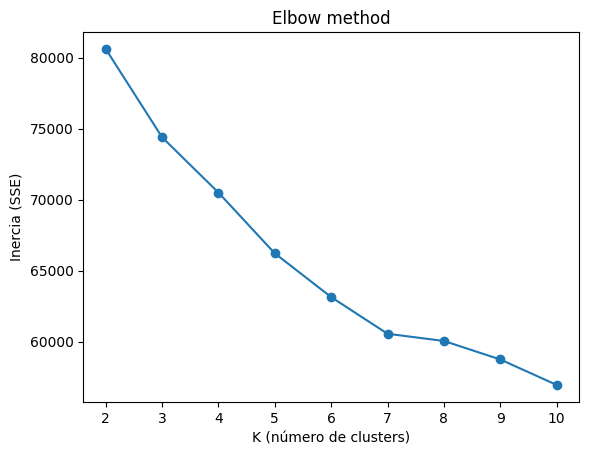

In [6]:
# 2.1 Elbow method (inercia)
ks = range(2, 11)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(ks), inertias, marker="o")
plt.xlabel("K (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.title("Elbow method")
plt.show()

---

## 6) K-Means – Silhouette Score

**Objetivo:**  
- Evaluar la calidad de los clusters para distintos valores de K.

**Qué hace este bloque:**  
- Paso 1: Ajusta K-Means para cada valor de K.  
- Paso 2: Obtiene las etiquetas de cluster.  
- Paso 3: Calcula el Silhouette Score.  
- Paso 4: Identifica el K con mejor separación.

**Inputs:**  
- `X`: matriz preprocesada.  
- Rango de valores de K.

**Outputs:**  
- `sil_scores`: Silhouette Score por K.  
- `best_k`: valor de K con mejor score.

**Notas / Buenas prácticas:**  
- Valores cercanos a 0 indican solapamiento entre clusters.  
- El mejor K matemático no siempre es el más útil para negocio.

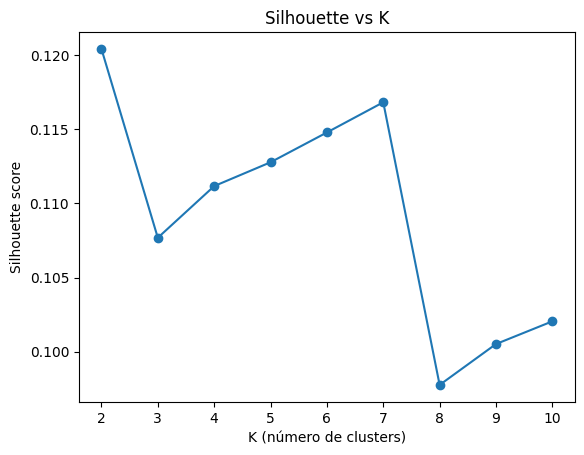

Best K según silhouette (2-10): 2 | score: 0.12043151063767905


In [7]:
# 2.2 Silhouette score
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

plt.figure()
plt.plot(list(ks), sil_scores, marker="o")
plt.xlabel("K (número de clusters)")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs K")
plt.show()

best_k = int(ks[int(np.argmax(sil_scores))])
print("Best K según silhouette (2-10):", best_k, "| score:", max(sil_scores))

---

## 7) Selección final de K

**Objetivo:**  
- Elegir un número de clusters que sea interpretable y accionable (3–5 segmentos).

**Qué hace este bloque:**  
- Paso 1: Restringe la búsqueda de K al rango requerido.  
- Paso 2: Selecciona el K con mejor Silhouette dentro de ese rango.

**Inputs:**  
- `sil_scores`: métricas calculadas.  

**Outputs:**  
- `chosen_k`: número final de clusters.

**Notas / Buenas prácticas:**  
- En segmentación de clientes, menos clusters suele facilitar la toma de decisiones.

In [ ]:
# Elegir K final: priorizamos 3-5 segmentos (requerimiento)
candidates = [k for k in range(3, 6)]
cand_scores = {k: sil_scores[list(ks).index(k)] for k in candidates if k in ks}
chosen_k = max(cand_scores, key=cand_scores.get) if len(cand_scores)>0 else best_k
print("K elegido (priorizando 3-5):", chosen_k, "| silhouette:", cand_scores.get(chosen_k, None))

K elegido (priorizando 3-5): 5 | silhouette: 0.11278047424058116


---

## 8) Entrenamiento final de K-Means y asignación de clusters

**Objetivo:**  
- Entrenar el modelo K-Means definitivo y asignar un cluster a cada cliente.

**Qué hace este bloque:**  
- Paso 1: Entrena K-Means con el K seleccionado.  
- Paso 2: Asigna etiquetas de cluster a cada observación.  
- Paso 3: Agrega la columna `cluster_kmeans` al DataFrame.

**Inputs:**  
- `X`: matriz preprocesada.  
- `chosen_k`: número de clusters.

**Outputs:**  
- `kmeans`: modelo entrenado.  
- `cluster_kmeans`: etiqueta de cluster por cliente.

**Notas / Buenas prácticas:**  
- Usar `random_state` asegura reproducibilidad.  
- Revisar el tamaño de los clusters resultantes.

In [9]:
# Entrenar K-Means final
kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init="auto")
kmeans_labels = kmeans.fit_predict(X)

df_k = df.copy()
df_k["cluster_kmeans"] = kmeans_labels

df_k["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    2114
1    2380
2    2164
3    1477
4    1865
Name: count, dtype: int64

## Interpretación:

Los segmentos están bastante balanceados (bueno para análisis).
No hay clusters ínfimos tipo “micro-grupos” (eso sería una alerta).

---

## 9) Interpretación de centroides de K-Means

**Objetivo:**  
- Analizar el perfil promedio de clientes en cada cluster.

**Qué hace este bloque:**  
- Paso 1: Extrae los centroides del modelo.  
- Paso 2: Revierte el escalado de variables numéricas.  
- Paso 3: Identifica categorías más representativas por cluster.

**Inputs:**  
- `kmeans.cluster_centers_`.  
- Transformadores de preprocesamiento.

**Outputs:**  
- Tabla con valores promedio por cluster.  
- Categorías dominantes por segmento.

**Notas / Buenas prácticas:**  
- Los centroides representan clientes “promedio”, no individuos reales.  
- Facilita traducir clusters a perfiles de negocio.

## Las variables que más “separan” segmentos tienden a ser:
- actividad (IsActiveMember)
- balance
- número de productos
- (edad aparece, pero menos dominante)

In [11]:
# Centroides en el espacio transformado
centroids = kmeans.cluster_centers_

# Separar parte numérica y categórica
num_centroids_scaled = centroids[:, :len(num_cols)]
cat_centroids = centroids[:, len(num_cols):]

# Invertir escalado numérico
scaler = preprocess.named_transformers_["num"]
num_centroids = scaler.inverse_transform(num_centroids_scaled)

centroids_df_num = pd.DataFrame(num_centroids, columns=num_cols)
centroids_df_num["cluster"] = range(chosen_k)

# Para categorías one-hot: mostrar top 3 categorías más representativas por cluster
cat_df = pd.DataFrame(cat_centroids, columns=cat_feature_names)
top_cats = {}
for c in range(chosen_k):
    top = cat_df.iloc[c].sort_values(ascending=False).head(3)
    top_cats[c] = list(top.index)

centroids_df_num["top_categorias"] = centroids_df_num["cluster"].map(top_cats)
display(centroids_df_num)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,cluster,top_categorias
0,652.598865,39.503784,4.864711,106136.355497,1.297067,7.771561e-16,5.307474e-01,101270.919697,0,"[Gender_Male, Gender_Female, Geography_France]"
1,646.262516,38.765250,5.105175,104320.611805,1.241481,1.000000e+00,-1.776357e-15,101077.797745,1,"[Gender_Male, Gender_Female, Geography_France]"
2,653.762477,39.487985,4.890481,121027.771687,1.330407,1.000000e+00,1.000000e+00,99207.983863,2,"[Gender_Male, Gender_Female, Geography_France]"
3,648.643243,36.422973,5.131757,13882.858088,2.141216,7.236486e-01,3.330669e-16,100114.416527,3,"[Geography_France, Gender_Male, Gender_Female]"
4,651.364075,39.787668,5.110456,5397.219946,1.909383,7.737265e-01,1.000000e+00,98497.767180,4,"[Geography_France, Gender_Male, Gender_Female]"


---

## 10) Visualización 2D de clusters con PCA (K-Means)

**Objetivo:**  
- Visualizar la estructura de los clusters en dos dimensiones.

**Qué hace este bloque:**  
- Paso 1: Reduce dimensionalidad con PCA (2 componentes).  
- Paso 2: Proyecta los datos al plano 2D.  
- Paso 3: Grafica puntos coloreados por cluster.

**Inputs:**  
- `X`: matriz preprocesada.  
- `cluster_kmeans`.

**Outputs:**  
- Gráfico 2D de clusters.  
- Varianza explicada por PC1 y PC2.

**Notas / Buenas prácticas:**  
- PCA se usa solo para visualización.  
- Solapamientos en 2D no implican mala segmentación en alta dimensión.

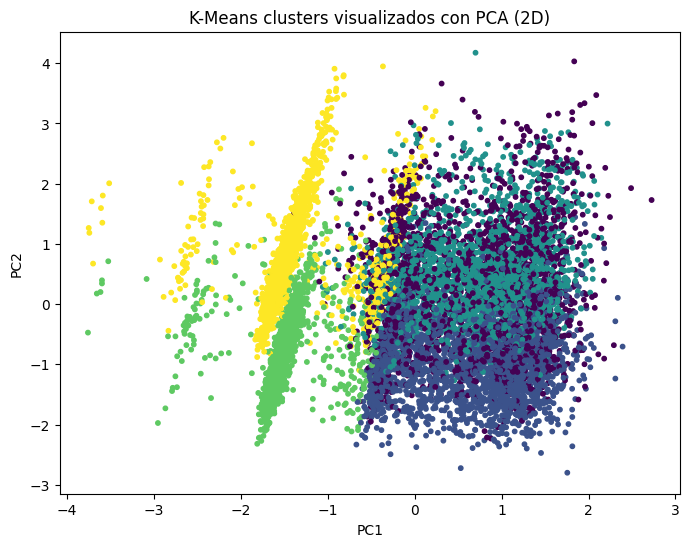

Varianza explicada PC1+PC2: 0.2672640391312031


In [12]:
pca_2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca_2.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=kmeans_labels, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means clusters visualizados con PCA (2D)")
plt.show()

print("Varianza explicada PC1+PC2:", pca_2.explained_variance_ratio_.sum())

---

## 11) DBSCAN – K-distance plot

**Objetivo:**  
- Obtener una referencia visual para elegir el parámetro `eps`.

**Qué hace este bloque:**  
- Paso 1: Calcula distancias al k-ésimo vecino.  
- Paso 2: Ordena las distancias.  
- Paso 3: Grafica el k-distance plot para identificar un codo.

**Inputs:**  
- `X`: matriz preprocesada.

**Outputs:**  
- Gráfico k-distance.

**Notas / Buenas prácticas:**  
- DBSCAN es muy sensible a `eps`.  
- El escalado previo es imprescindible.

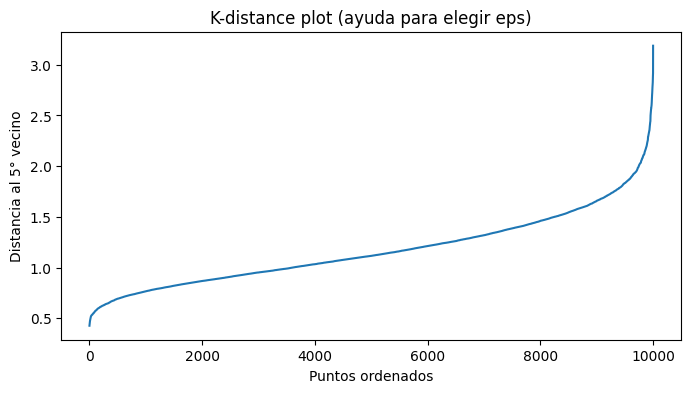

In [ ]:
# Sugerencia visual para eps: k-distance plot (distancia al k-ésimo vecino)
k = 5  # suele relacionarse con min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8,4))
plt.plot(k_dist)
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k}° vecino")
plt.title("K-distance plot (ayuda para elegir eps)")
plt.show()

---

## 12) DBSCAN – Entrenamiento y selección de parámetros

**Objetivo:**  
- Evaluar distintas configuraciones de DBSCAN y seleccionar una razonable.

**Qué hace este bloque:**  
- Paso 1: Prueba distintos valores de `eps`.  
- Paso 2: Calcula cantidad de clusters, ruido y silhouette (cuando aplica).  
- Paso 3: Selecciona la mejor configuración.  
- Paso 4: Entrena el modelo final y asigna etiquetas.

**Inputs:**  
- `X`: matriz preprocesada.  
- Lista de valores `eps`.

**Outputs:**  
- `cluster_dbscan`: etiquetas DBSCAN (incluye -1 como ruido).

**Notas / Buenas prácticas:**  
- El cluster `-1` representa outliers.  
- DBSCAN no siempre produce clusters bien definidos en datos tabulares.

In [14]:
# Probar DBSCAN con algunos eps candidatos alrededor del 'codo' visual
def run_dbscan(eps, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = np.mean(labels == -1)
    sil = None
    # silhouette solo si hay >= 2 clusters y no todos son ruido
    if n_clusters >= 2 and (noise_frac < 1.0):
        try:
            sil = silhouette_score(X[labels!=-1], labels[labels!=-1])
        except Exception:
            sil = None
    return labels, n_clusters, noise_frac, sil

eps_candidates = [0.6, 0.8, 1.0, 1.2]
results = []
for eps in eps_candidates:
    labels, n_clusters, noise_frac, sil = run_dbscan(eps, min_samples=5)
    results.append((eps, n_clusters, noise_frac, sil))

dbscan_summary = pd.DataFrame(results, columns=["eps", "n_clusters", "noise_frac", "silhouette (sin ruido)"])
display(dbscan_summary)

,eps,n_clusters,noise_frac,silhouette (sin ruido)
0,0.6,48,0.9560,0.392807
1,0.8,132,0.7551,0.089374
2,1.0,131,0.4586,-0.003991
3,1.2,109,0.2389,0.003499


In [15]:
# Elegir configuración razonable automáticamente:
# - Al menos 2 clusters
# - Ruido no excesivo (<= 0.5)
# - Maximizar silhouette si existe
valid = dbscan_summary[(dbscan_summary["n_clusters"]>=2) & (dbscan_summary["noise_frac"]<=0.5)].copy()

if len(valid)>0 and valid["silhouette (sin ruido)"].notna().any():
    best_row = valid.sort_values("silhouette (sin ruido)", ascending=False).iloc[0]
else:
    # fallback: el que tenga más clusters con ruido moderado
    best_row = valid.sort_values(["n_clusters","noise_frac"], ascending=[False, True]).iloc[0] if len(valid)>0 else dbscan_summary.iloc[0]

best_eps = float(best_row["eps"])
print("eps elegido:", best_eps)

dbscan = DBSCAN(eps=best_eps, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

df_k["cluster_dbscan"] = dbscan_labels

pd.Series(dbscan_labels).value_counts().sort_index()

eps elegido: 1.2


-1      2389
 0       328
 1         5
 2       108
 3       438
        ... 
 104       6
 105       4
 106       5
 107       4
 108       5
Name: count, Length: 110, dtype: int64

### Visualización 2D DBSCAN (PCA)
Se grafican las etiquetas DBSCAN en el espacio PCA 2D. El ruido aparece como `-1`.


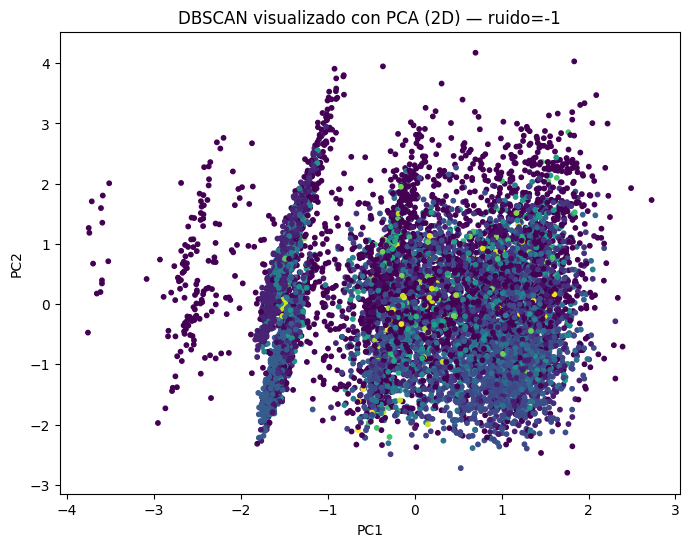

In [16]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca2[:,0], X_pca2[:,1], c=dbscan_labels, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN visualizado con PCA (2D) — ruido=-1")
plt.show()

---

## 13) Reducción de dimensionalidad con PCA

**Objetivo:**  
- Analizar cuánta varianza explican los componentes principales.

**Qué hace este bloque:**  
- Paso 1: Ajusta PCA completo.  
- Paso 2: Calcula varianza explicada y acumulada.  
- Paso 3: Determina el número de componentes necesarios.

**Inputs:**  
- `X`: matriz preprocesada.

**Outputs:**  
- Gráfico de varianza explicada acumulada.  
- Número de componentes para explicar el 90% de la varianza.

**Notas / Buenas prácticas:**  
- PCA es útil tanto para visualización como para compresión.

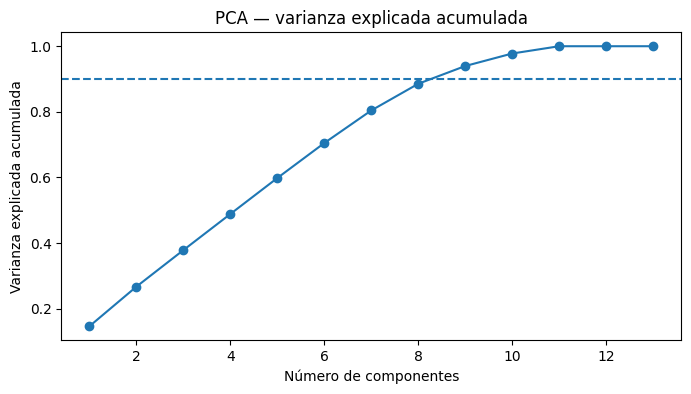

Componentes para ~90% varianza: 9


In [17]:
# PCA: varianza explicada acumulada
pca_full = PCA(random_state=RANDOM_STATE)
X_pca = pca_full.fit_transform(X)

expl = pca_full.explained_variance_ratio_
cum_expl = np.cumsum(expl)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(cum_expl)+1), cum_expl, marker="o")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA — varianza explicada acumulada")
plt.axhline(0.9, linestyle="--")
plt.show()

n_90 = int(np.argmax(cum_expl>=0.90)+1)
print("Componentes para ~90% varianza:", n_90)

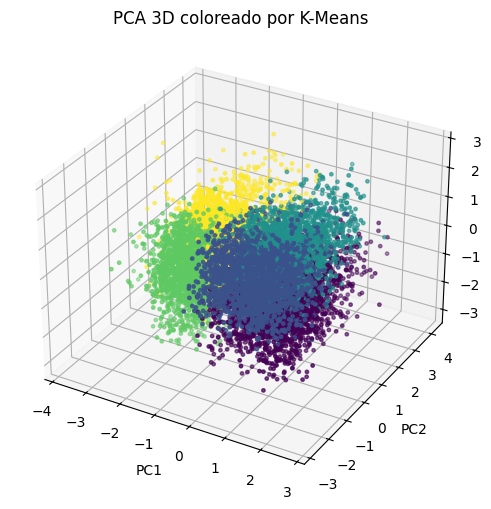

Varianza explicada PC1+PC2+PC3: 0.3785797899000529


In [18]:
# Visualización PCA 3D (si hay soporte)
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3 = pca_3.fit_transform(X)

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:,0], X_pca3[:,1], X_pca3[:,2], c=kmeans_labels, s=6)
ax.set_title("PCA 3D coloreado por K-Means")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
plt.show()

print("Varianza explicada PC1+PC2+PC3:", pca_3.explained_variance_ratio_.sum())

In [19]:
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

def top_loadings(pc, n=10):
    return loadings[pc].abs().sort_values(ascending=False).head(n)

print("Top loadings PC1:")
display(top_loadings("PC1", 12))
print("Top loadings PC2:")
display(top_loadings("PC2", 12))

Top loadings PC1:


Balance              0.715044
NumOfProducts        0.663450
Age                  0.134710
Geography_Germany    0.124614
Geography_France     0.089148
Tenure               0.058536
HasCrCard            0.043869
Geography_Spain      0.035466
CreditScore          0.010355
Gender_Female        0.009689
Gender_Male          0.009689
IsActiveMember       0.004258
Name: PC1, dtype: float64

Top loadings PC2:


IsActiveMember       0.684037
Age                  0.595526
Tenure               0.288470
HasCrCard            0.200400
CreditScore          0.165879
EstimatedSalary      0.125309
Balance              0.074800
NumOfProducts        0.070063
Geography_Spain      0.012509
Geography_Germany    0.009450
Gender_Male          0.006671
Gender_Female        0.006671
Name: PC2, dtype: float64

---
### Interpretación de componentes principales
Los **loadings** indican qué variables contribuyen más a cada componente.
A continuación se listan las variables con mayor peso absoluto en PC1 y PC2.

- PC1 dominado por: Balance y NumOfProducts
- PC2 dominado por: IsActiveMember y Age

**Interpretación:** La variabilidad principal del dataset está explicada principalmente por Balance y cantidad de productos (PC1), y por actividad y edad (PC2).

---

## 14) t-SNE para visualización no lineal

**Objetivo:**  
- Explorar patrones no lineales y agrupamientos locales en los datos.

**Qué hace este bloque:**  
- Paso 1: Reduce dimensionalidad previamente con PCA.  
- Paso 2: Aplica t-SNE en 2D.  
- Paso 3: Visualiza puntos coloreados por cluster.

**Inputs:**  
- `X`: matriz preprocesada.  
- `cluster_kmeans`.

**Outputs:**  
- Gráfico t-SNE 2D.

**Notas / Buenas prácticas:**  
- t-SNE es solo para visualización.  
- No interpretar distancias globales.

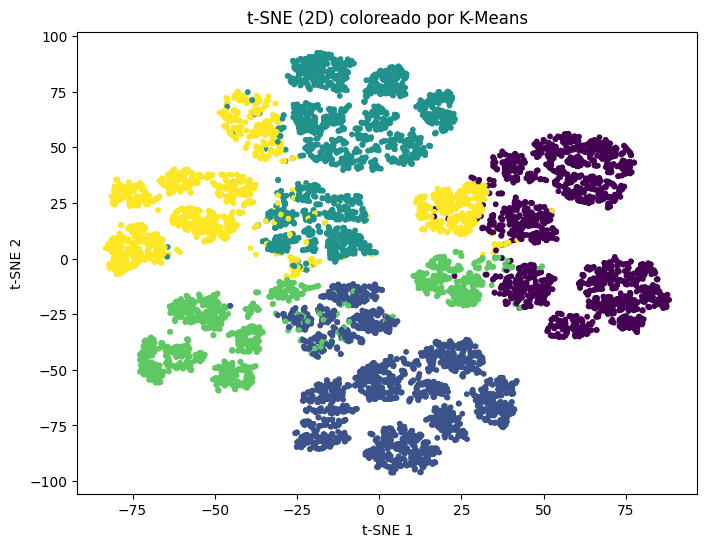

In [20]:
# t-SNE puede ser costoso. Para mejorar estabilidad, reducimos primero con PCA a 30 dims (práctica común).
pca_30 = PCA(n_components=min(30, X.shape[1]), random_state=RANDOM_STATE)
X_pca30 = pca_30.fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)
X_tsne2 = tsne.fit_transform(X_pca30)

plt.figure(figsize=(8,6))
plt.scatter(X_tsne2[:,0], X_tsne2[:,1], c=kmeans_labels, s=10)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (2D) coloreado por K-Means")
plt.show()

---
**Interpretación:** t-SNE se utilizó como herramienta exploratoria de visualización para identificar agrupamientos locales, sin inferir relaciones globales.

---

## 15) Churn por segmento (K-Means y DBSCAN)

**Objetivo:**  
- Analizar la tasa de churn en cada segmento identificado.

**Qué hace este bloque:**  
- Paso 1: Agrupa clientes por cluster.  
- Paso 2: Calcula la tasa promedio de churn.  
- Paso 3: Visualiza diferencias entre segmentos.

**Inputs:**  
- `cluster_kmeans`, `cluster_dbscan`.  
- `Exited`.

**Outputs:**  
- Tablas de churn por cluster.  
- Gráficos comparativos.

**Notas / Buenas prácticas:**  
- El clustering no predice churn, pero ayuda a interpretarlo.  
- Segmentos con churn alto son candidatos a estrategias de retención.

,count,churn_rate
cluster_kmeans,,
1,2380,0.325630
0,2114,0.244560
3,1477,0.153690
2,2164,0.149261
4,1865,0.104558


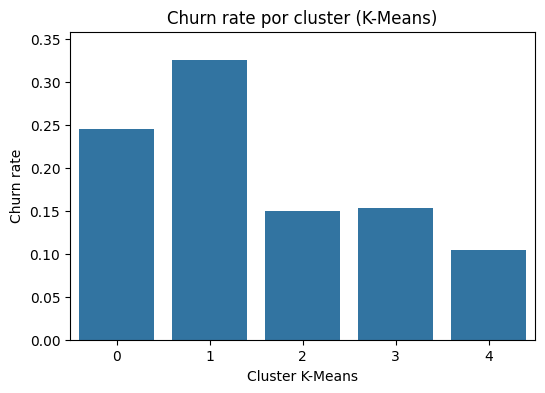

In [21]:
# Tasa de churn por cluster K-Means
churn_by_k = df_k.groupby("cluster_kmeans")["Exited"].agg(["count","mean"]).rename(columns={"mean":"churn_rate"})
display(churn_by_k.sort_values("churn_rate", ascending=False))

plt.figure(figsize=(6,4))
sns.barplot(x=churn_by_k.index, y=churn_by_k["churn_rate"])
plt.xlabel("Cluster K-Means")
plt.ylabel("Churn rate")
plt.title("Churn rate por cluster (K-Means)")
plt.ylim(0, churn_by_k["churn_rate"].max()*1.1)
plt.show()

### Perfil de clientes por cluster
Construimos un perfil con promedios de variables numéricas y distribución de categorías por cluster.

In [22]:
# Perfil numérico por cluster K-Means
profile_num = df_k.groupby("cluster_kmeans")[num_cols + ["Exited"]].mean()
display(profile_num)

# Distribuciones de categorías
for c in cat_cols:
    display(
        pd.crosstab(df_k["cluster_kmeans"], df_k[c], normalize="index")
        .style.format("{:.2f}")
        .set_caption(f"Distribución de {c} por cluster K-Means")
    )

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
cluster_kmeans,,,,,,,,,
0,652.598865,39.503784,4.864711,106136.355497,1.297067,0.000000,0.530747,101270.919697,0.244560
1,646.225630,38.756303,5.101681,104308.183126,1.242437,1.000000,0.000000,101123.984248,0.325630
2,653.762477,39.487985,4.890481,121027.771687,1.330407,1.000000,1.000000,99207.983863,0.149261
3,648.707515,36.432634,5.137441,13719.193223,2.141503,0.723087,0.000000,100038.036012,0.153690
4,651.364075,39.787668,5.110456,5397.219946,1.909383,0.773727,1.000000,98497.767180,0.104558


Geography,France,Germany,Spain
cluster_kmeans,,,
0,0.44,0.33,0.23
1,0.44,0.36,0.20
2,0.40,0.39,0.21
3,0.63,0.06,0.32
4,0.66,0.02,0.32


Gender,Female,Male
cluster_kmeans,,
0,0.46,0.54
1,0.46,0.54
2,0.43,0.57
3,0.47,0.53
4,0.45,0.55


### Comparación con DBSCAN y churn
DBSCAN puede detectar **ruido** (outliers) y clusters de forma arbitraria.

,count,churn_rate
cluster_dbscan,,
40,4,1.0
107,4,1.0
97,5,0.8
75,5,0.6
37,5,0.6
...,...,...
99,7,0.0
100,5,0.0
101,5,0.0


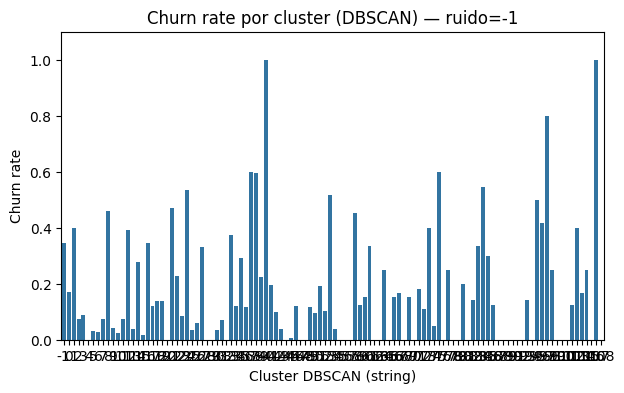

In [23]:
# Churn por cluster DBSCAN (incluye -1 = ruido)
churn_by_db = df_k.groupby("cluster_dbscan")["Exited"].agg(["count","mean"]).rename(columns={"mean":"churn_rate"})
display(churn_by_db.sort_values("churn_rate", ascending=False))

plt.figure(figsize=(7,4))
sns.barplot(x=churn_by_db.index.astype(str), y=churn_by_db["churn_rate"])
plt.xlabel("Cluster DBSCAN (string)")
plt.ylabel("Churn rate")
plt.title("Churn rate por cluster (DBSCAN) — ruido=-1")
plt.ylim(0, churn_by_db["churn_rate"].max()*1.1)
plt.show()

---

## 16) Feature engineering a partir del clustering

**Objetivo:**  
- Crear nuevas variables que puedan enriquecer modelos supervisados posteriores.

**Qué hace este bloque:**  
- Paso 1: Calcula distancia de cada cliente a su centroide.  
- Paso 2: Agrega columnas de cluster y distancia.  
- Paso 3: Construye un dataset final con nuevas features.

**Inputs:**  
- `X`: matriz preprocesada.  
- Modelo K-Means entrenado.

**Outputs:**  
- Nuevas variables:  
  - `cluster_kmeans`  
  - `cluster_dbscan`  
  - `kmeans_dist_to_centroid`

**Notas / Buenas prácticas:**  
- Estas features capturan estructura no supervisada.  
- Suelen mejorar el desempeño de modelos supervisados.

In [24]:
from sklearn.metrics import pairwise_distances

# Distancia de cada punto a cada centroide (en espacio transformado)
dists = pairwise_distances(X, kmeans.cluster_centers_)
dist_to_assigned = dists[np.arange(X.shape[0]), kmeans_labels]
df_k["kmeans_dist_to_centroid"] = dist_to_assigned

# Feature final (ejemplo) para modelos supervisados: mantener columnas originales + nuevas
feature_df = df_k.drop(columns=drop_cols)  # conserva Exited y demás
display(feature_df.head())

print("Nuevas features agregadas:", ["cluster_kmeans","cluster_dbscan","kmeans_dist_to_centroid"])

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,cluster_kmeans,cluster_dbscan,kmeans_dist_to_centroid
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,4,0,2.196901
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1,2.195285
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,-1,3.527572
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,3,2,2.413462
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,2,-1,2.694100


Nuevas features agregadas: ['cluster_kmeans', 'cluster_dbscan', 'kmeans_dist_to_centroid']


> ## Conclusión integrradora: En este avance se aplicaron técnicas de clustering y reducción de dimensionalidad para identificar patrones no supervisados en el comportamiento de los clientes. K-Means permitió definir cinco segmentos interpretables, con diferencias claras en la tasa de churn. En particular, los clientes inactivos presentaron una probabilidad de abandono significativamente mayor, mientras que los segmentos con mayor actividad mostraron mayor retención. DBSCAN aportó valor para la detección de clientes atípicos, aunque no resultó adecuado para segmentación estratégica. Finalmente, se generaron features derivadas del clustering que podrán ser utilizadas en modelos supervisados posteriores, integrando los aprendizajes no supervisados al pipeline predictivo.